In [1]:
import numpy as np

# 1. Definimos los datos del problema (vectores como arrays de NumPy)
x = np.array([-1, 1, 1])  # Vector de entradas [x0, x1, x2]
w = np.array([1, 1, 1])   # Vector de pesos iniciales [w0, w1, w2]
d = -1                    # Salida deseada
mu = 0.5                  # Tasa de aprendizaje (mu)

print(f"Pesos iniciales: {w}")

# 2. Calculamos la salida actual (y)
# np.dot hace el "producto interno" (suma de w_i * x_i) automáticamente
suma_ponderada = np.dot(w, x) 

# Función de activación: signo (sgn)
y = np.sign(suma_ponderada)
# (Si la suma es 0, np.sign devuelve 0. Lo forzamos a 1 o -1 según convenga, aquí asumimos 1)
if y == 0: y = 1 

print(f"Suma ponderada: {suma_ponderada} -> Salida obtenida (y): {y}")

# 3. Regla de actualización
error = d - y  # En tu apunte esto es (-1 - 1) = -2

if error != 0:
    print(f"¡Hay error! (d={d} pero y={y}). Actualizando pesos...")
    # Aquí aplicamos tu fórmula: w(n + 1) = w(n) + 2 * mu * e(n) * x(n)
    w = w + 2 * mu * error * x
    print(f"Nuevos pesos actualizados: {w}")
else:
    print("La salida es correcta. No hay que actualizar pesos.")

Pesos iniciales: [1 1 1]
Suma ponderada: 1 -> Salida obtenida (y): 1
¡Hay error! (d=-1 pero y=1). Actualizando pesos...
Nuevos pesos actualizados: [ 3. -1. -1.]


In [2]:

# Nueva prueba con los pesos actualizados
y = np.sign(np.dot(w, x))
if y == 0: y = 1
print(f"Después de la actualización, nueva salida obtenida (y): {y}")

error = d - y
print(f"Nuevo error después de la actualización: {error}\n")

Después de la actualización, nueva salida obtenida (y): -1.0
Nuevo error después de la actualización: 0.0



## Prueba de Librería: Pandas

*Cargar datos de un .csv*

In [10]:
import pandas as pd

headers = ['x', 'w', 'd']

df = pd.read_csv('../Data/gtp-1/OR_50_trn.csv', header=None, names=headers) # el CSV viene sin 'nombre' de columna, le aplico uno yo

print(df.head()) # Mostrar primeras 5 filas de la tabla
print("\n")
print(df.info()) # Mostrar información relacionada (Relevante: cantidad de datos no nulos)
print("\n")
print(df.describe()) # Mostrar datos estadísticos


### Se pueden hacer mas operaciones avanzadas con la tabla... ###


         x        w  d
0  0.83988 -0.70249  1
1  1.16370 -1.40440  1
2  1.32610 -1.07280  1
3  1.17770 -0.99857  1
4  1.44610  0.99694  1


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1000 non-null   float64
 1   w       1000 non-null   float64
 2   d       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


                 x            w            d
count  1000.000000  1000.000000  1000.000000
mean      0.003024    -0.012499     0.500000
std       1.041225     1.025142     0.866459
min      -1.499400    -1.484000    -1.000000
25%      -0.995408    -1.008375     0.500000
50%      -0.000370    -0.006000     1.000000
75%       1.018550     0.965732     1.000000
max       1.492800     1.480000     1.000000


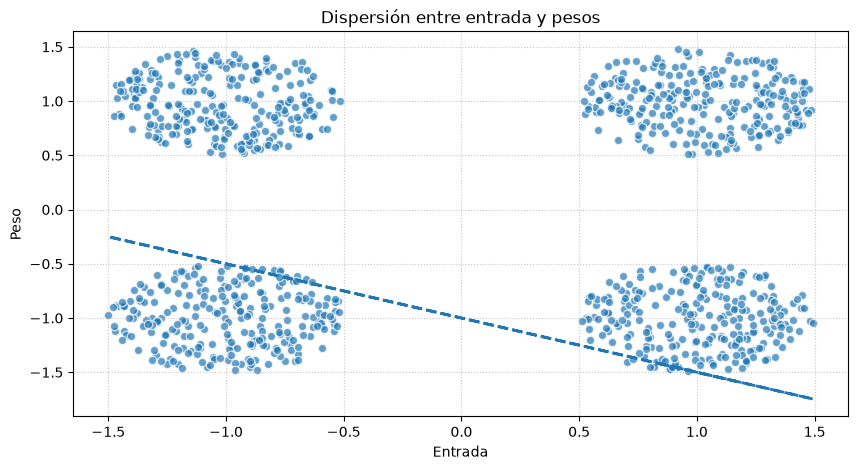

In [17]:
import numpy as np 
import matplotlib.pyplot as plt

x = df['x'].to_numpy()
w = df['w'].to_numpy()
d = df['d'].to_numpy()

plt.figure(1, figsize=(10,5))

plt.scatter(x, w, alpha=0.7, edgecolors='w')

y_tend = -(0.5 * x) - 1

plt.plot(x, y_tend, linewidth=2, linestyle='--')

plt.title('Dispersión entre entrada y pesos')
plt.xlabel('Entrada')
plt.ylabel('Peso')
plt.grid(True, linestyle=':', alpha=0.7)

# plt.show() # En jupyter no es necesario hacer el show()
